In [1]:
import pandas as pd
import numpy as np
from math import log2

In [2]:
data = {
    'Outlook': ['Sunny','Sunny','Overcast','Rain','Rain','Rain','Overcast','Sunny','Sunny','Rain','Sunny','Overcast','Overcast','Rain'],
    'Temperature': ['Hot','Hot','Hot','Mild','Cool','Cool','Mild','Cool','Mild','Mild','Mild','Mild','Hot','Mild'],
    'Humidity': ['High','High','High','High','Normal','Normal','Normal','High','Normal','Normal','Normal','High','Normal','High'],
    'Wind': ['Weak','Strong','Weak','Weak','Weak','Strong','Strong','Weak','Weak','Weak','Strong','Strong','Weak','Strong'],
    'PlayTennis': ['No','No','Yes','Yes','Yes','No','Yes','No','Yes','Yes','Yes','Yes','Yes','No']
}

df = pd.DataFrame(data)
print(df.head())

    Outlook Temperature Humidity    Wind PlayTennis
0     Sunny         Hot     High    Weak         No
1     Sunny         Hot     High  Strong         No
2  Overcast         Hot     High    Weak        Yes
3      Rain        Mild     High    Weak        Yes
4      Rain        Cool   Normal    Weak        Yes


In [3]:
def entropy(target_col):
    values, counts = np.unique(target_col, return_counts=True)
    probs = counts / counts.sum()
    return -np.sum(probs * np.log2(probs))

base_entropy = entropy(df['PlayTennis'])
print(f"Base Entropy H(Y): {base_entropy:.4f}")

Base Entropy H(Y): 0.9403


In [4]:
def information_gain(df, feature, target):
    base_entropy = entropy(df[target])
    values, counts = np.unique(df[feature], return_counts=True)

    weighted_entropy = 0
    for v, c in zip(values, counts):
        subset = df[df[feature] == v]
        weighted_entropy += (c / len(df)) * entropy(subset[target])

    return base_entropy - weighted_entropy


In [5]:
features = df.columns[:-1]
ig_results = {}

for feature in features:
    ig = information_gain(df, feature, 'PlayTennis')
    ig_results[feature] = ig
    print(f"Information Gain for {feature}: {ig:.4f}")

Information Gain for Outlook: 0.2467
Information Gain for Temperature: 0.1620
Information Gain for Humidity: 0.1518
Information Gain for Wind: 0.0481


In [6]:
best_feature = max(ig_results, key=ig_results.get)
print(f"\nBest feature to split on: {best_feature}")


Best feature to split on: Outlook


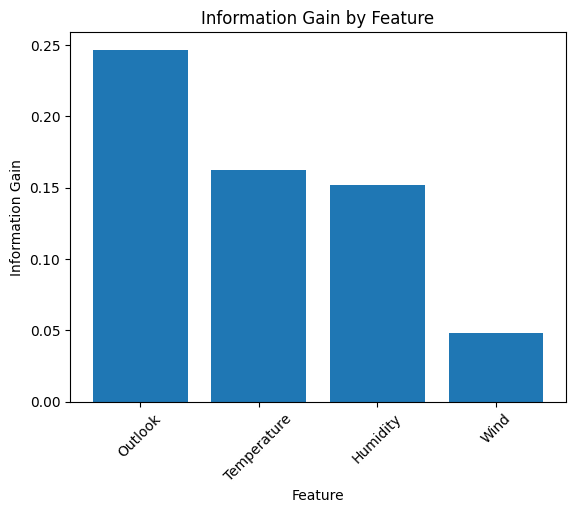

In [7]:
import matplotlib.pyplot as plt

plt.bar(ig_results.keys(), ig_results.values())
plt.title("Information Gain by Feature")
plt.xlabel("Feature")
plt.ylabel("Information Gain")
plt.xticks(rotation=45)
plt.show()

- Entropy measures uncertainty in the target (PlayTennis)
- Information Gain tells us how much a feature reduces that uncertainty
- The best feature is the one with the highest Information Gain